In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
transform=transforms.Compose([
    transforms.Resize((128,128)),    
    transforms.ToTensor()
])

aug_trans = transforms.Compose([
    transforms.Resize((128,128)), 
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [3]:
seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [4]:
DATA_DIR = r'C:\Users\MJ\Desktop\seg\seg_train'
model_algo="alexnet"


In [5]:
#建立dataset class
class ImageDataset(Dataset):
    def __init__(self, root,trans,decision_mode=False):
        super().__init__()
        self.images = ImageFolder(root=root)
        self.classes = self.images.class_to_idx.items()
        self.flag= [True] * len(self.images)
        self.decision_mode=decision_mode
        self.transform = trans

        # self.aug_trans = trans2
        # self.sum=0
    def __len__(self):
        return len(self.images)
   
    def __getitem__(self,idx):
        image, label=self.images[idx]

        # if(self.flag[idx]==True):
        image=self.transform(image)
        # else:
        #     image=self.aug_trans(image)
        #     self.sum+=1

        if(self.decision_mode==True):
            label=int(self.flag[idx])
            
        return image,label,idx
    
    def update_flag(self, idx):
        self.flag[idx] = False
    

In [6]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(123)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size),generator=generator)


In [7]:
# create data loaders
batch_size = 64 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()
idx2class = {v: k for k, v in trainset.dataset.classes}

In [8]:
#建立模型框架
def model_create(model_algo,data_name):
    model = getattr(models,model_algo)(weights=True)
    for param in model.features.parameters():
        param.requires_grad = False
    if(data_name=='decision'):
        class_number=2
    else:
        class_number=len(trainset.dataset.classes)

    if(model_algo=='googlenet' or model_algo=='resnet18' ):
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, class_number)
    else :
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs,class_number)
    
    return model

In [9]:
#模型表現
def evaluate_model(model,data_dl,size):
        model.to(device)
        ######################    
        # validate the model #
        ######################
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
                model.eval()   

                for data, target,idx in data_dl:

                        data,target=data.to(device),target.to(device)
                        out= model(data)
                        _, y_pred_tag = torch.max(out, dim = 1)
                        loss = criterion(out, target)
                        
                        flat_true.extend(target.cpu().numpy())
                        flat_pred.extend(y_pred_tag.cpu().numpy())

                        total_loss+= loss.item()*data.size(0)
                        correct=torch.sum(y_pred_tag == target).item()
                        accu += correct      

                total_loss=total_loss/size
                accu=accu/size
        confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
        return total_loss,accu,confusion_matrix_valid

In [10]:
    
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                    data,target=data.to(device),target.to(device)
                    out_growth= model_0(data)
                    _, decision_tag = torch.max(out_growth, dim = 1)

                    for result,d,t in zip(torch.eq(target,decision_tag),data,target):
                            if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                                out = model(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

In [11]:

def evaluate_model_decision(model):
        correct=0
        flat_true=[]
        flat_pred=[]
        decision_valid_accu=0
        with torch.no_grad():
                model_0.eval()   
                for data, target,idx in valid_dl:

                        data,target=data.to(device),target.to(device)
                        out_growth= model_0(data)   #原始model
                        _, y_pred_tag = torch.max(out_growth, dim = 1)

                        out_predict= model(data)  #預測要用哪個model
                        _, predict = torch.max(out_predict, dim = 1)
        
                        for pred,result in zip(predict,torch.eq(target,y_pred_tag)):
                                if(result==pred):
                                        correct+=1
                                flat_true.append(result.cpu().numpy())
                                flat_pred.append(pred.cpu().numpy())

        decision_valid_accu=correct/valid_size

        print("decision_valid accu=",decision_valid_accu) 
        confusion_matrix_decision_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
        return  decision_valid_accu,confusion_matrix_decision_valid

In [12]:
#訓練模型
def trainer(epochs,model,criterion,optim,data_dl,data_name):
        train_accus=[]
        val_accus=[]
        best_val_accu = 0.0
        epochs_without_improvement = 0
        overfitting = 0
        patience=5
       

        for epoch in range(epochs):
                
                train_loss=0
                model.to(device)
                model.train()
                ###################
                # train the model #
                ###################
                for data, target,idx in data_dl:
                        
                        optim.zero_grad()
                        data,target=data.to(device),target.to(device)  #將data、target放到gpu上
                      
                        out = model(data)
                        # _, y_pred_tag = torch.max(out, dim = 1)  
                        
                        loss = criterion(out, target)
                        loss.backward()
                        optim.step()
                        # print(target)
                
                      
                train_loss,train_accu,_=evaluate_model(model,data_dl,len(data_dl.dataset))
                print(f"Epoch={epoch},train_loss={train_loss},train_accu={train_accu}")
                train_accus.append(train_accu)
                
                if(data_name=="T" or data_name=="F"):  
                        
                        val_loss,val_accu,_=evaluate_model_TF(model,data_name)
                elif(data_name=="decision"):
                        val_accu,_=evaluate_model_decision(model)
                else:
                        val_loss,val_accu,_=evaluate_model(model,valid_dl,valid_size)
                        print(f"Epoch={epoch},valid_loss={val_loss},valid_accu={val_accu}")

                val_accus.append(val_accu)
        
                # Early stopping
                if val_accu > best_val_accu:
                        best_val_accu = val_accu
                        epochs_without_improvement = 0
                        best_model=copy.deepcopy(model)
                        print(f"{epochs_without_improvement}")
                # elif (train_accu-best_val_accu>0.02):
                #         overfitting += 1
                        
                else:
                        epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                        print(f"{epochs_without_improvement} Early stopping!")
                        break
                # elif overfitting >= patience:
                #         print("Early stopping overfit!")
                #         break
                
                torch.save(best_model, f"model_{model_algo}_{data_name}_{epoch}.pth")               
        plt.plot(train_accus,'-o')
        plt.plot(val_accus,'-o')

        plt.xlabel('epoch')
        plt.ylabel('Accuracy')
        plt.legend(['Train','Valid'])
        plt.show()
        torch.save(best_model, f"model_{model_algo}_{data_name}.pth")  
        return best_model
                

In [13]:
#將模型建立框架後並訓練
def model_train(model_algo,data_dl,data_name,epochs,class_weight=None):
    
    model=model_create(model_algo,data_name)
    if(data_name=="decision"):
        trainset.dataset.decision_mode=True
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4,weight_decay=1e-3)
        criterion = nn.CrossEntropyLoss(weight=class_weight)
        
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
        trainset.dataset.decision_mode=False
    else:
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
    torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model

In [14]:
# model_0=model_train(model_algo,train_dl,"0",20)
model_0 = torch.load(f'model_{model_algo}_0_3.pth')

In [15]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size)
train_loss,train_accu

(0.1866312352816264, 0.9340880503144654)

In [16]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size)
valid_loss,valid_accu

(0.3444189108466304, 0.8837345860246624)

In [17]:
#將資料切分成true and false
def split_data(model_0,data_dl):
    model_0.eval()
  
    indexF=[]
    indexT=[]
    with torch.no_grad():

        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            # print(y_pred_tag)
            for idx,t,tag in zip(idx,target,y_pred_tag):

                if(t==tag):
                    indexT.append(idx.cpu().numpy().item())
                    
                else:
                    indexF.append(idx.cpu().numpy().item())
                    trainset.dataset.update_flag(idx)
            
        torch.cuda.empty_cache() 
    return indexF,indexT

In [51]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
indexF,indexT=split_data(model_0,train_dl)

# Fdataset=Subset(trainset, indexF)
# Tdataset=Subset(trainset, indexT)
# Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
# Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
decision_dl = DataLoader(trainset, batch_size=64)

In [19]:
len(indexF),len(indexT)

(786, 11139)

In [54]:
targets=[target for _,target,_ in trainset]
flag_counts=[len(indexF),len(indexT)]
total_sample=sum(flag_counts)
w=[total_sample / count for count in flag_counts] 
weights = [w[0]-8 if t == 0 else w[1] for t in targets]
w[0]+=4
w=torch.tensor(w).cuda()

In [21]:
# w

tensor([19.1718,  1.0706], device='cuda:0')

In [55]:
sampler = WeightedRandomSampler(weights, len(trainset), replacement=True)
trainset.dataset.decision_mode=True
decision_dl = DataLoader(trainset, batch_size=64,sampler=sampler)
trainset.dataset.decision_mode=False

In [56]:
# trainset.dataset.decision_mode=True
# data=[data.numpy() for data ,_,_ in trainset]
# targets=[target for _,target,_ in trainset]
# trainset.dataset.decision_mode=False

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.440836080400199,train_accu=0.7506918238993711
decision_valid accu= 0.5281855549031121
0
Epoch=1,train_loss=0.6519547914908866,train_accu=0.6232285115303984
decision_valid accu= 0.6861421021726365
0
Epoch=2,train_loss=0.420565608417463,train_accu=0.7685534591194969
decision_valid accu= 0.5584263065179096
Epoch=3,train_loss=0.4788493851245824,train_accu=0.7110272536687631
decision_valid accu= 0.6670581327069877
Epoch=4,train_loss=0.5697807416775942,train_accu=0.6852830188679245
decision_valid accu= 0.6594245449207281
Epoch=5,train_loss=0.2490190711511256,train_accu=0.8688469601677149
decision_valid accu= 0.42924251321197887
Epoch=6,train_loss=0.4480105301719042,train_accu=0.7319916142557652
decision_valid accu= 0.6570757486788021
5 Early stopping!


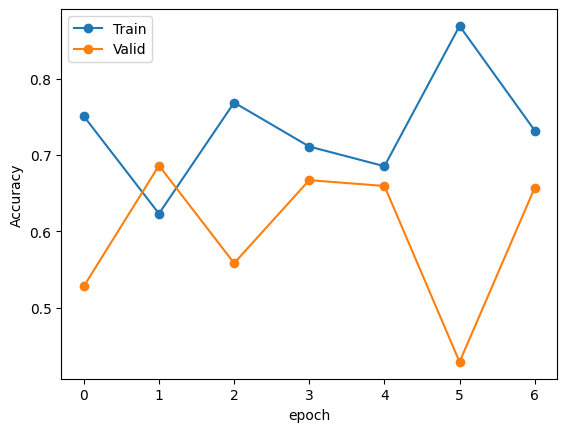

In [57]:
model_decision=model_train(model_algo,decision_dl,"decision",50,w)
# model_decision = torch.load(f'model_{model_algo}_decision.pth')

In [25]:
trainset.decision_mode=True
decision_F=[]
decision_T=[]
model_decision.eval()
model_0.eval()
sumF=0
sumT=0
with torch.no_grad():
    for (data,target,idx) in decision_dl:
        data,target=data.cuda(),target.cuda()
        out = model_decision(data)
        _, decision_tag = torch.max(out, dim = 1) 

        for idx,dtag ,t in zip(idx,decision_tag,target):
            
            if(dtag==t==1):
                sumT+=1
                decision_T.append(idx.cpu().numpy().item())
            elif(dtag==t==0):
                decision_F.append(idx.cpu().numpy().item())
            else:
                decision_T.append(idx.cpu().numpy().item())
                decision_F.append(idx.cpu().numpy().item())
                
    torch.cuda.empty_cache() 
    trainset.decision_mode=False
    
Fdataset=Subset(images, decision_F)
Tdataset=Subset(images, decision_T)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)


In [26]:
sumT

912

In [27]:
len(decision_F),len(Tdataset)

(11013, 10038)

In [28]:
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                    data,target=data.to(device),target.to(device)
                    out_growth= model_decision(data)
                    _, decision_tag = torch.max(out_growth, dim = 1)

                    for result,d,t in zip(decision_tag,data,target):
                            if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                                out = model(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.1513348791193834,train_accu=0.9481968519625423
Model_T valid loss=0.337702349078145, accu=0.9021739130434783,sample_number=1288
0
Epoch=1,train_loss=0.09835874360232126,train_accu=0.9675234110380554
Model_T valid loss=0.3970741651787638, accu=0.90527950310559,sample_number=1288
0
Epoch=2,train_loss=0.08582781467376703,train_accu=0.9699143255628612
Model_T valid loss=0.3845352981689785, accu=0.8998447204968945,sample_number=1288
Epoch=3,train_loss=0.059029589871972245,train_accu=0.9823670053795577
Model_T valid loss=0.4204563657015985, accu=0.90527950310559,sample_number=1288
Epoch=4,train_loss=0.03470747566589513,train_accu=0.9902370990237099
Model_T valid loss=0.4306879574031593, accu=0.9099378881987578,sample_number=1288
0
Epoch=5,train_loss=0.029003997010660018,train_accu=0.9917314206017135
Model_T valid loss=0.4577520825115483, accu=0.9099378881987578,sample_number=1288
Epoch=6,train_loss=0.022383563977954372,train_accu=0.9943215780035863
Model_T valid loss=0.4

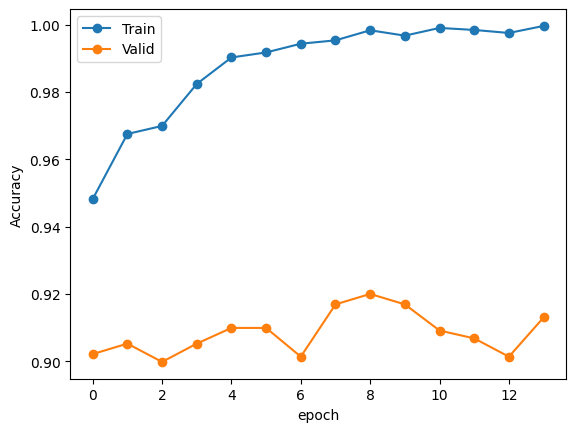

In [29]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,"T",20)
# model_T=torch.load(f'model_{model_algo}_T.pth')

In [30]:
# targets=[target for _,target,_ in Fdataset]
# import collections
# class_counts = collections.Counter(targets)
# total_sample=len(Fdataset)

# w = [0] * 6

# for i,count in class_counts.items():
#     w[i]=total_sample/count

# w[1]-=40

# for i in range(2,6):
#     w[i]+=40
   
# w=torch.tensor(w).cuda()

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.23834675729334284,train_accu=0.9179151911377463
Model_F valid loss=0.5397002364398907, accu=0.8054768649669499,sample_number=2118
0
Epoch=1,train_loss=0.15492159672183625,train_accu=0.9408880414056116
Model_F valid loss=0.6806096542632835, accu=0.7653446647780925,sample_number=2118
Epoch=2,train_loss=0.0765690410697949,train_accu=0.977571960410424
Model_F valid loss=0.4758629187222994, accu=0.8352219074598678,sample_number=2118
0
Epoch=3,train_loss=0.05558061807492573,train_accu=0.985380913465904
Model_F valid loss=0.5023821331666481, accu=0.8347497639282342,sample_number=2118
Epoch=4,train_loss=0.049989583401516324,train_accu=0.9865613366021974
Model_F valid loss=0.5472178560351553, accu=0.8234183191690274,sample_number=2118
Epoch=5,train_loss=0.028562764024324252,train_accu=0.9936438754199582
Model_F valid loss=0.5707476597905866, accu=0.8314447592067988,sample_number=2118
Epoch=6,train_loss=0.021060780442267717,train_accu=0.9940070825388178
Model_F valid loss=0.

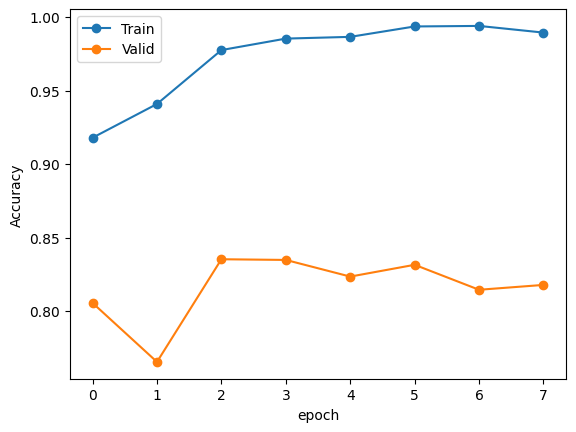

In [31]:
model_F=model_train(model_algo,Fdl,"F",20)
# model_F=torch.load(f'model_{model_algo}_F.pth')

In [32]:
torch.cuda.empty_cache()

In [33]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset))
T_loss,T_accu

(0.013477804425945733, 0.9983064355449293)

In [34]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset))
F_loss,F_accu

(0.07656903933213792, 0.977571960410424)

In [35]:
trainset.dataset.decision_mode

False

In [36]:
trainset.dataset.decision_mode=True
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,train_size)
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"buildings":"False","forest":"True"}, index={"buildings":"False","forest":"True"})
trainset.dataset.decision_mode=False
decision_loss,decision_accu

(0.714508232020732, 0.6167714884696017)

In [37]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model_TF(model_T,"T")
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model_TF(model_F,"F")


Model_T valid loss=0.4664876690023382, accu=0.9200310559006211,sample_number=1288
Model_F valid loss=0.47586291872229947, accu=0.8352219074598678,sample_number=2118


In [38]:
decision_valid_accu,confusion_matrix_decision_valid=evaluate_model_decision(model_decision )
# confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})

decision_valid accu= 0.4357017028772754


In [39]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]


    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_decision(data)
            _, y_pred_tag = torch.max(out, dim = 1)
            
        
            for pred,d,t in zip(y_pred_tag,data,target):
                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    

                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    
           
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)
        

            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())
            
            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total

In [40]:
total_train_loss,total_train_accu,confusion_matrix_total_train=total_model_evaluate(train_dl,train_size)
total_train_loss,total_train_accu

(0.2599770421801873, 0.9141299790356394)

In [41]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid=total_model_evaluate(valid_dl,valid_size)
total_valid_loss,total_valid_accu

(0.4723176058607107, 0.8672930123311803)

In [42]:
def plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,model_name):
    fig = plt.figure(figsize=(15, 5))
    ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)

    sns.heatmap(confusion_matrix_train, annot=True, fmt='',cbar=False,ax=ax1,square=True).set(title=f"{model_algo}_{model_name} train confusion matrix", xlabel="Predicted Label", ylabel="True Label")
    sns.heatmap(confusion_matrix_valid, annot=True, fmt='',ax=ax2,square=True).set(title=f"{model_algo}_{model_name} valid confusion matrix", xlabel="Predicted Label", ylabel="True Label")


In [43]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu]
valid_losses=[valid_loss,"NA",T_valid_loss,F_valid_loss,total_valid_loss]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu]

In [44]:
model_algos=['Model_0',"Model_decision","Model_T","Model_F","Total_Model"]
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.186631,0.934088,0.344419,0.883735
1,Model_decision,0.714508,0.616771,NA,0.435702
2,Model_T,0.013478,0.998306,0.466488,0.920031
3,Model_F,0.076569,0.977572,0.475863,0.835222
4,Total_Model,0.259977,0.914130,0.472318,0.867293


In [45]:
len(Fdataset),len(Tdataset)

(11013, 10038)

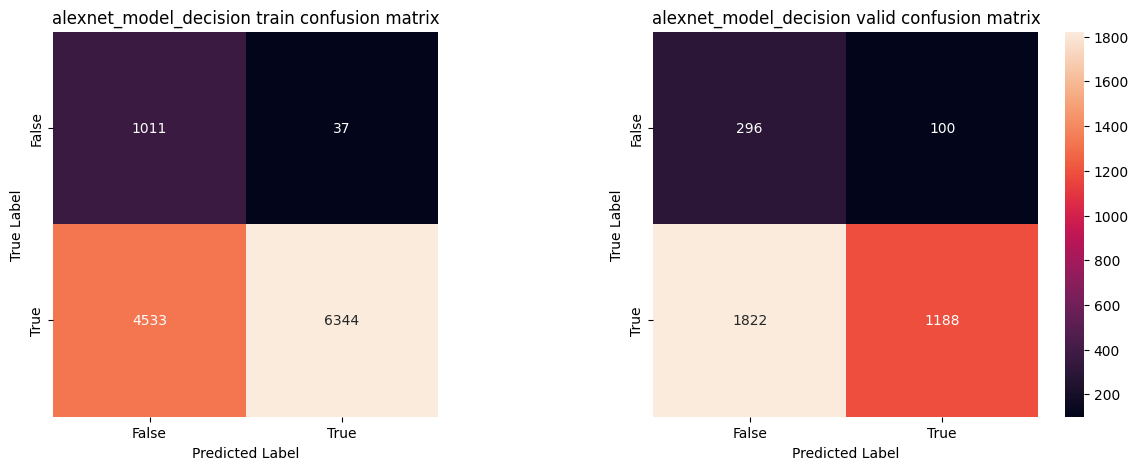

In [46]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision")

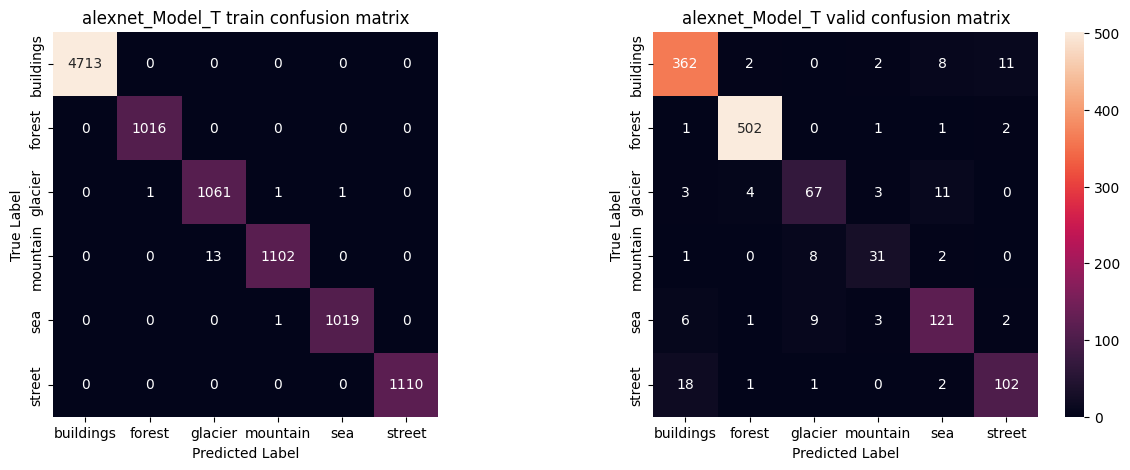

In [47]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T")

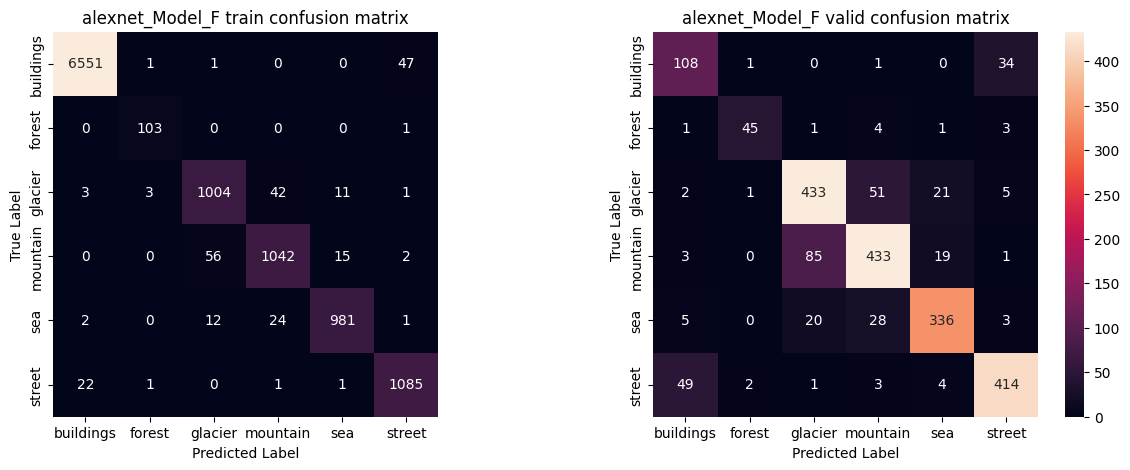

In [48]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F")

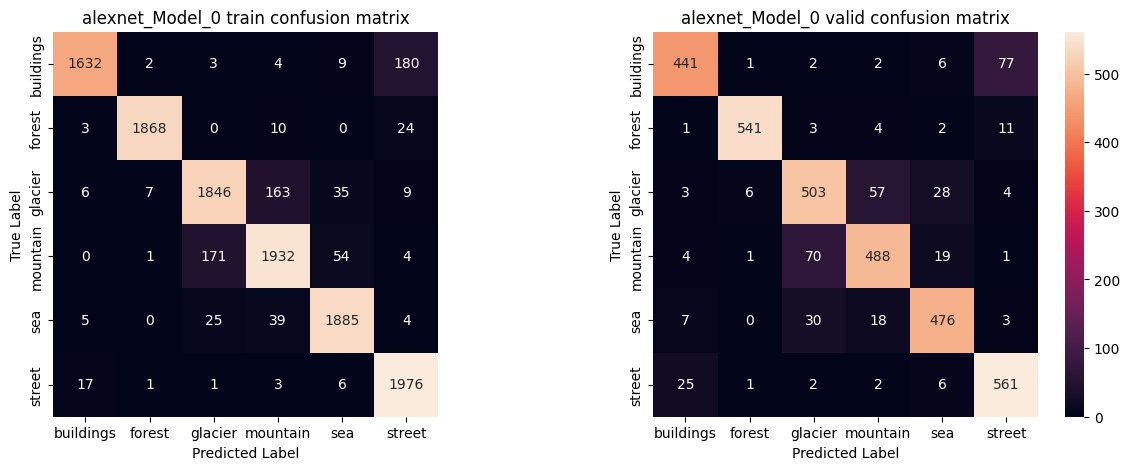

In [49]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0")

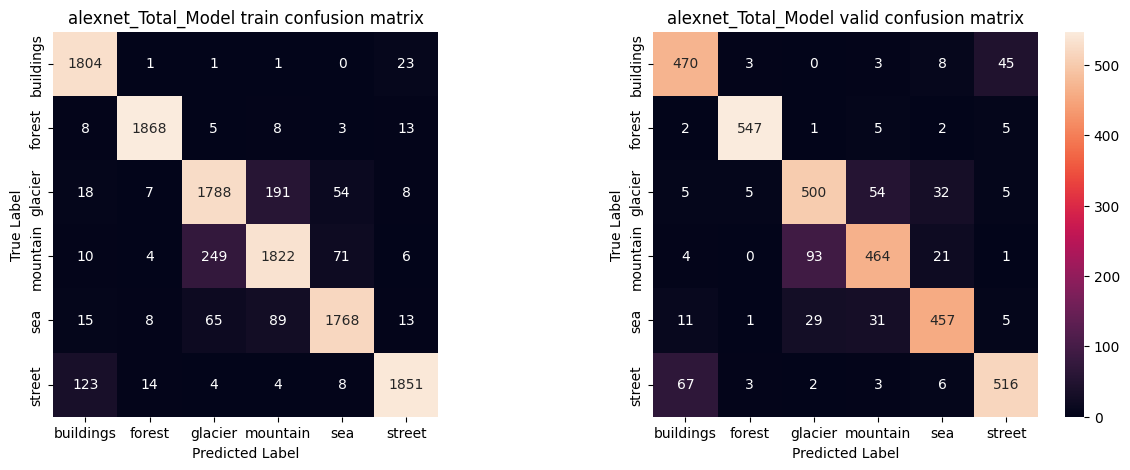

In [50]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model")